# INDIVIDUAL HOUSEHOLD ELECTRIC POWER CONSUMPTION


## Parte 1 

(Ingest -  Data Quality - EDA)

# 1. Librerías


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Ingesta

In [2]:
%run src/ingestion/ingest.py

Ingesta completada
Archivos guardados en: C:\Curso Base de Datos\Proyecto-Household-Power-G7\data\raw


# 3. Preprocesamiento

## 3.1 Análisis del dataset


In [3]:
ROOT_DIR = Path.cwd()
RAW_FILE = ROOT_DIR / "data" / "raw" / "household_power_consumption.txt"

cols_9 = [
    "Date",
    "Time",
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
]

eraw = pd.read_csv(
    RAW_FILE,
    sep=";",
    na_values=["?"],
    low_memory=False,
    encoding="latin1",
    usecols=cols_9,
)
eraw = eraw[cols_9]
assert eraw.shape[1] == 9

eraw.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [4]:
print("Dimensión:", eraw.shape)
print("Número de filas:", eraw.shape[0])
print("Número de columnas:", eraw.shape[1])
print("Columnas:", list(eraw.columns))

Dimensión: (2075259, 9)
Número de filas: 2075259
Número de columnas: 9
Columnas: ['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']


Hallazgos:
* El dataset contiene 2,075,259 registros y 9 columnas.
* Las columnas conformadas por las siguientes variables:
    Date
    Time
    Global_active_power
    Global_reactive_power
    Voltage
    Global_intensity
    Sub_metering_1
    Sub_metering_2
    Sub_metering_3
* El dataset cuenta con la misma cantidad de registros que el archivo fuente, esto confirma que la ingesta se realizó sin pérdida de información.

## 3.2 Nulos

In [5]:
if "eraw" not in globals():
    from pathlib import Path

    ROOT_DIR = Path(r"C:\Users\Eve\OneDrive\Desktop\PROYECTO")
    RAW_FILE = ROOT_DIR / "data" / "raw" / "household_power_consumption.txt"
    cols_9 = [
        "Date",
        "Time",
        "Global_active_power",
        "Global_reactive_power",
        "Voltage",
        "Global_intensity",
        "Sub_metering_1",
        "Sub_metering_2",
        "Sub_metering_3",
    ]

    eraw = pd.read_csv(
        RAW_FILE,
        sep=";",
        na_values=["?"],
        low_memory=False,
        encoding="latin1",
        usecols=cols_9,
    )
    eraw = eraw[cols_9]

vars_9 = [
    "Date",
    "Time",
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
]

faltantes = eraw[vars_9].isna().sum()

resumen_faltantes = pd.DataFrame({
    "Variable": faltantes.index,
    "Faltantes": faltantes.values,
    "%": ((faltantes / len(eraw)) * 100).round(2)
})

display(resumen_faltantes)


,Variable,Faltantes,%
Date,Date,0,0.00
Time,Time,0,0.00
Global_active_power,Global_active_power,25979,1.25
Global_reactive_power,Global_reactive_power,25979,1.25
Voltage,Voltage,25979,1.25
Global_intensity,Global_intensity,25979,1.25
Sub_metering_1,Sub_metering_1,25979,1.25
Sub_metering_2,Sub_metering_2,25979,1.25
Sub_metering_3,Sub_metering_3,25979,1.25


Hallazgos:
* Al revisar los valores nulos y los valores faltantes codificados mediante símbolos, se obtuvo que `Date` y `Time` no presentan valores nulos, mientras que las 7 variables restantes registran 25,979 faltantes, equivalentes al 1.25%.


## 3.3 Duplicados

In [6]:
df = eraw.copy()

duplicados_exactos = df[df.duplicated(keep=False)].copy()
num_duplicados_exactos = int(df.duplicated().sum())

duplicados_fecha_hora = df[df.duplicated(subset=["Date", "Time"], keep=False)].copy()
num_duplicados_fecha_hora = int(df.duplicated(subset=["Date", "Time"]).sum())

resumen_duplicados = pd.DataFrame({
    "Tipo": ["Duplicados exactos", "Duplicados por fecha y hora"],
    "Registros": [num_duplicados_exactos, num_duplicados_fecha_hora],
    "%": [
        round(num_duplicados_exactos / len(df) * 100, 2),
        round(num_duplicados_fecha_hora / len(df) * 100, 2),
    ],
})

print(f"Duplicados exactos: {num_duplicados_exactos}")
print(f"Duplicados por fecha y hora: {num_duplicados_fecha_hora}")
display(resumen_duplicados)
display(duplicados_exactos)
display(duplicados_fecha_hora)


Duplicados exactos: 0
Duplicados por fecha y hora: 0


,Tipo,Registros,%
0,Duplicados exactos,0,0.0
1,Duplicados por fecha y hora,0,0.0


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3


Hallazgos:
* Duplicados exactos: 0, por lo tanto no hay filas idénticas considerando las 9 variables del dataset.
* Duplicados por fecha y hora: 0, lo que indica que no se repiten combinaciones de `Date` y `Time`.


## 3.4 Registros inconsistentes

In [7]:
df = eraw.copy()

fecha_hora = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce",
)

columnas_numericas = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
]

for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")

mascara_inconsistencias = (
    fecha_hora.isna()
    | (df[columnas_numericas] < 0).any(axis=1)
    | (df["Voltage"] <= 0)
)

total_inconsistencias = mascara_inconsistencias.sum()
print(f"Total de otras inconsistencias: {total_inconsistencias}")


Total de otras inconsistencias: 0


Hallazgo: No se encontraron inconsistencias.
* No se detectaron fechas y horas inválidas, valores negativos en variables numéricas ni `Voltage` menor o igual a 0.


## 3.5 Categorías inconsistentes

In [8]:
from pandas.api.types import is_numeric_dtype, is_datetime64_any_dtype, is_object_dtype, is_string_dtype

df = eraw.copy()

def es_texto(serie):
    return is_string_dtype(serie) or is_object_dtype(serie)

def cumple_tipo(serie, esperado):
    if esperado == "numérico":
        return is_numeric_dtype(serie)
    if esperado == "texto":
        return es_texto(serie)
    return False

especificaciones = {
    "Date": "texto",
    "Time": "texto",
    "Global_active_power": "numérico",
    "Global_reactive_power": "numérico",
    "Voltage": "numérico",
    "Global_intensity": "numérico",
    "Sub_metering_1": "numérico",
    "Sub_metering_2": "numérico",
    "Sub_metering_3": "numérico",
}

resumen_tipos = pd.DataFrame([
    {
        "Columna": col,
        "Dtype_observado": str(df[col].dtype) if col in df.columns else "No existe",
        "Tipo_esperado": esperado,
        "Cumple": cumple_tipo(df[col], esperado) if col in df.columns else False,
    }
    for col, esperado in especificaciones.items()
])

display(resumen_tipos)


,Columna,Dtype_observado,Tipo_esperado,Cumple
0,Date,str,texto,True
1,Time,str,texto,True
2,Global_active_power,float64,numérico,True
3,Global_reactive_power,float64,numérico,True
4,Voltage,float64,numérico,True
5,Global_intensity,float64,numérico,True
6,Sub_metering_1,float64,numérico,True
7,Sub_metering_2,float64,numérico,True
8,Sub_metering_3,float64,numérico,True


Hallazgos: 
* No se identificaron columnas con tipo de dato incorrecto en el conjunto analizado. 
* Este nos indica que, la estructura del dataset es consistente y que, al menos en términos de formato y tipificación, los datos pueden utilizarse sin requerir correcciones previas.

## 3.6 Fechas y datos inválidos

In [9]:
df = eraw.copy()

fecha_hora = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce",
)

total_fechas_invalidas = int(fecha_hora.isna().sum())
print(f"Total de fechas u horas inválidas: {total_fechas_invalidas}")

columnas_numericas = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
]
for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")

mascara_datos_imposibles = (
    (df["Voltage"] <= 0)
    | (df["Global_active_power"] < 0)
    | (df["Global_reactive_power"] < 0)
    | (df["Global_intensity"] < 0)
    | (df[["Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]] < 0).any(axis=1)
)

total_datos_imposibles = int(mascara_datos_imposibles.sum())
print(f"Total de datos imposibles: {total_datos_imposibles}")


Total de fechas u horas inválidas: 0
Total de datos imposibles: 0


Hallazgos:
* En el dataset analizado no se identificaron fechas inválidas ni datos imposibles. 
* Esto sugiere que la información revisada presenta consistencia básica en su estructura temporal.

## 3.7 Errores de Unidad

Éste cálculo nos dice cuantos registros parecen tener una inconsistencia entre la energía total y la energía medida por los submedidores. 

En concreto, hace esto:
- Toma Global_active_power, que está en kW.
- Lo convierte a Wh por minuto con * 1000 / 60.
- Resta el consumo registrado en: Sub_metering_1, Sub_metering_2 ySub_metering_3

¿Qué significa el resultado?
- Si es positivo, todavía hay consumo activo no explicado por los submeterings. Eso es normal y esperado.
- Si es negativo, significa que la suma de los submeterings supera el consumo total estimado, lo cual es físicamente sospechoso.

In [10]:
df = eraw.copy()

# Columnas necesarias para la validación de unidad
columnas = [
    "Global_active_power",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
]

for col in columnas:
    df[col] = pd.to_numeric(df[col], errors="coerce")

base = df[columnas].dropna().copy()

# Global_active_power está en kW y los sub_meterings en Wh por minuto
base["residual_wh"] = (
    base["Global_active_power"] * 1000 / 60
    - base[["Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]].sum(axis=1)
)

total_errores_unidad = int((base["residual_wh"] < 0).sum())

print(f"Total de posibles errores de unidad: {total_errores_unidad}")


Total de posibles errores de unidad: 1050


Hallagos:
* El total de posibles errores es de 1.050. 
* La suma de los submedidores superó la energía total estimada a partir de Global_active_power, lo que genera un residual negativo. 
* En términos prácticos, esto pudiera deberse a inconsistencias físicas o de unidad.
* Como proporción del dataset, esto representa aproximadamente 0.05% del total de filas. Eso sugiere que no es un problema generalizado, sino casos puntuales que conviene revisar para determinar como conviene tratarlos según el objetivo de nuestro proyecto por lo que se procede a su análisis:

### 3.7.1 Análisis de inconsistencias en el balance energético

In [11]:
df = eraw.copy()

columnas_numericas = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
]

for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["residual_wh"] = (
    df["Global_active_power"] * 1000 / 60
    - df[["Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]].sum(axis=1)
)

df["posible_error_unidad"] = df["residual_wh"] < 0

df_ok = df.loc[~df["posible_error_unidad"]].copy()
df_bad = df.loc[df["posible_error_unidad"]].copy()

print(f"Registros sospechosos: {len(df_bad):,} ({len(df_bad) / len(df) * 100:.2f}%)")
print(f"Registros válidos: {len(df_ok):,} ({len(df_ok) / len(df) * 100:.2f}%)")

columnas_comparar = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
    "residual_wh",
]

comparacion = pd.DataFrame({
    "media_total": df[columnas_comparar].mean(),
    "media_sin_sospechosos": df_ok[columnas_comparar].mean(),
    "media_sospechosos": df_bad[columnas_comparar].mean(),
})

comparacion["dif_abs"] = comparacion["media_sospechosos"] - comparacion["media_sin_sospechosos"]
comparacion["dif_pct"] = (
    comparacion["dif_abs"] / comparacion["media_sin_sospechosos"] * 100
).round(2)

display(comparacion.sort_values(by="dif_pct", key=lambda s: s.abs(), ascending=False))

corr_total = df["Global_active_power"].corr(df["Global_intensity"])
corr_sin = df_ok["Global_active_power"].corr(df_ok["Global_intensity"])
corr_con = df_bad["Global_active_power"].corr(df_bad["Global_intensity"])

print(f"Correlación total: {corr_total:.3f}")
print(f"Correlación sin sospechosos: {corr_sin:.3f}")
print(f"Correlación en sospechosos: {corr_con:.3f}")


Registros sospechosos: 1,050 (0.05%)
Registros válidos: 2,074,209 (99.95%)


,media_total,media_sin_sospechosos,media_sospechosos,dif_abs,dif_pct
Sub_metering_2,1.298520,1.297700,2.898095,1.600395,123.33
residual_wh,9.314693,9.319619,-0.293651,-9.613270,-103.15
Sub_metering_1,1.121923,1.121460,2.026667,0.905207,80.72
Global_active_power,1.091615,1.091935,0.467581,-0.624354,-57.18
Global_intensity,4.627759,4.629018,2.172571,-2.456447,-53.07
Sub_metering_3,6.458447,6.460137,3.161905,-3.298233,-51.06
Global_reactive_power,0.123714,0.123710,0.131691,0.007981,6.45
Voltage,240.839858,240.840076,240.414381,-0.425695,-0.18


Correlación total: 0.999
Correlación sin sospechosos: 0.999
Correlación en sospechosos: 0.997


Hallazgos:
* Tal y como se señaló previamente, se destinguieron 1,050 registros posibles de errores de unidad, equivalentes al 0.05% del total.
* Por su parte los registros del archivo fuente (2,074,209) se mantuvieron como válidos en un 99.95%.
* Al comparar los subgrupos, media_sin_sospechoso y media_sospechosos, se observó:
                    * En Sub_metering_2 la mayor diferencia absoluta (dif_abs = 1.60) y porcentual (dif_pct = 123.33%), lo que indica un incremento marcado en los registros sospechosos respecto a los válidos.
                    * Aumentos en Sub_metering_1 (dif_abs = 0.90, dif_pct = 80.72%).
                    * En contraste, Global_active_power, Global_intensity y Sub_metering_3 presentaron promedios inferiores en los registros sospechosos. 
                    * Por su parte, Voltage mostró una variación mínima (dif_abs = -0.43, dif_pct = -0.18%).
* La correlación entre Global_active_power y Global_intensity se mantuvo en 0.999, lo que sugiere un impacto limitado sobre la estructura global del dataset. 
* Si bien el 0.05% de los registros sí tienen una inconsistencia en el balance energético, no alteran de forma significativa el comportamiento global del dataset. Por lo que se concluye que, conservar ese 0.05% de registros dentro del conjunto. 

## 3.8 Gaps temporales

In [12]:
df = eraw.copy()

fecha_hora = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce",
)

serie_tiempo = fecha_hora.dropna().sort_values()
gaps_minutos = serie_tiempo.diff().dt.total_seconds().div(60)
total_gaps = int((gaps_minutos > 1).sum())

print(f"Total de gaps temporales: {total_gaps}")


Total de gaps temporales: 0


Hallazgo: 
* No se identificaron gaps temporales en la serie analizada, lo que indica que los registros mantienen una continuidad consistente a nivel minuto a minuto.

## 3.9 Leakage o Fuga de Informacion

Ocurre cuando el modelo usa datos que en la vida real no tendría disponibles al momento de predecir.

In [13]:
df = eraw.copy()

target_col = "Global_active_power" 
columnas_numericas = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
]

for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")
reporte_leakage = []

for col in columnas_numericas:
    if col == target_col:
        continue
    pares = df[[target_col, col]].dropna()
    if pares.empty:
        continue
    corr = pares[target_col].corr(pares[col])

    reporte_leakage.append({
        "columna": col,
        "corr": corr,
        "corr_abs": abs(corr),
        "igual_al_objetivo": df[col].equals(df[target_col]),
    })

reporte_leakage = pd.DataFrame(reporte_leakage).sort_values(
    by="corr_abs",
    ascending=False
)
posibles_leakage = reporte_leakage[(reporte_leakage["igual_al_objetivo"]) | (reporte_leakage["corr_abs"] >= 0.95)]
print(f"Posibles casos de leakage: {len(posibles_leakage)}")
display(posibles_leakage)


Posibles casos de leakage: 1


,columna,corr,corr_abs,igual_al_objetivo
2,Global_intensity,0.998889,0.998889,False


Hallazgos:
* La prueba señala una posible fuga de información debido a la alta correlación entre Global_intensity y la variable objetivo (0.998889). 
* El script la marcó como posible leakage porque supera el umbral de correlación (0.95).
* Al revisar la literatura en temas de electricidad se encontró que ambas variables se encuentran altamente relacionadas:
                * En una casa de habitación la corriente térmica se mueve casi de forma proporcinal a la potencia. 
* Concluyendose que, no hay fuga de información, sino, *una alta multicolinealidad.*

## 3.10 Análisis Estadístico Exploratorio (EDA)

### 3.10.1 EDA Variables Numéricas

In [14]:
vars_numericas = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
]

if "eraw" not in globals():
    eraw = pd.read_csv(
        RAW_FILE,
        sep=";",
        na_values=["?"],
        low_memory=False,
        usecols=vars_numericas,
    )

df = eraw.copy()

num = df[vars_numericas].apply(pd.to_numeric, errors="coerce")
resumen = num.describe().round(4)
resumen.loc["CV (%)"] = ((num.std() / num.mean().replace(0, np.nan)) * 100).round(2)
resumen.loc["moda"] = num.mode(dropna=True).iloc[0]
resumen.loc["skewness"] = num.skew().round(4)
resumen.loc["kurtosis"] = num.kurtosis().round(4)

display(resumen)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091600e+00,1.237000e-01,2.408399e+02,4.627800e+00,1.121900e+00,1.298500e+00,6.458400e+00
std,1.057300e+00,1.127000e-01,3.240000e+00,4.444400e+00,6.153000e+00,5.822000e+00,8.437200e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01
CV (%),9.686000e+01,9.111000e+01,1.350000e+00,9.604000e+01,5.484400e+02,4.483600e+02,1.306400e+02
moda,2.180000e-01,0.000000e+00,2.411800e+02,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


### 3.10.2 Histogramas de Skewness

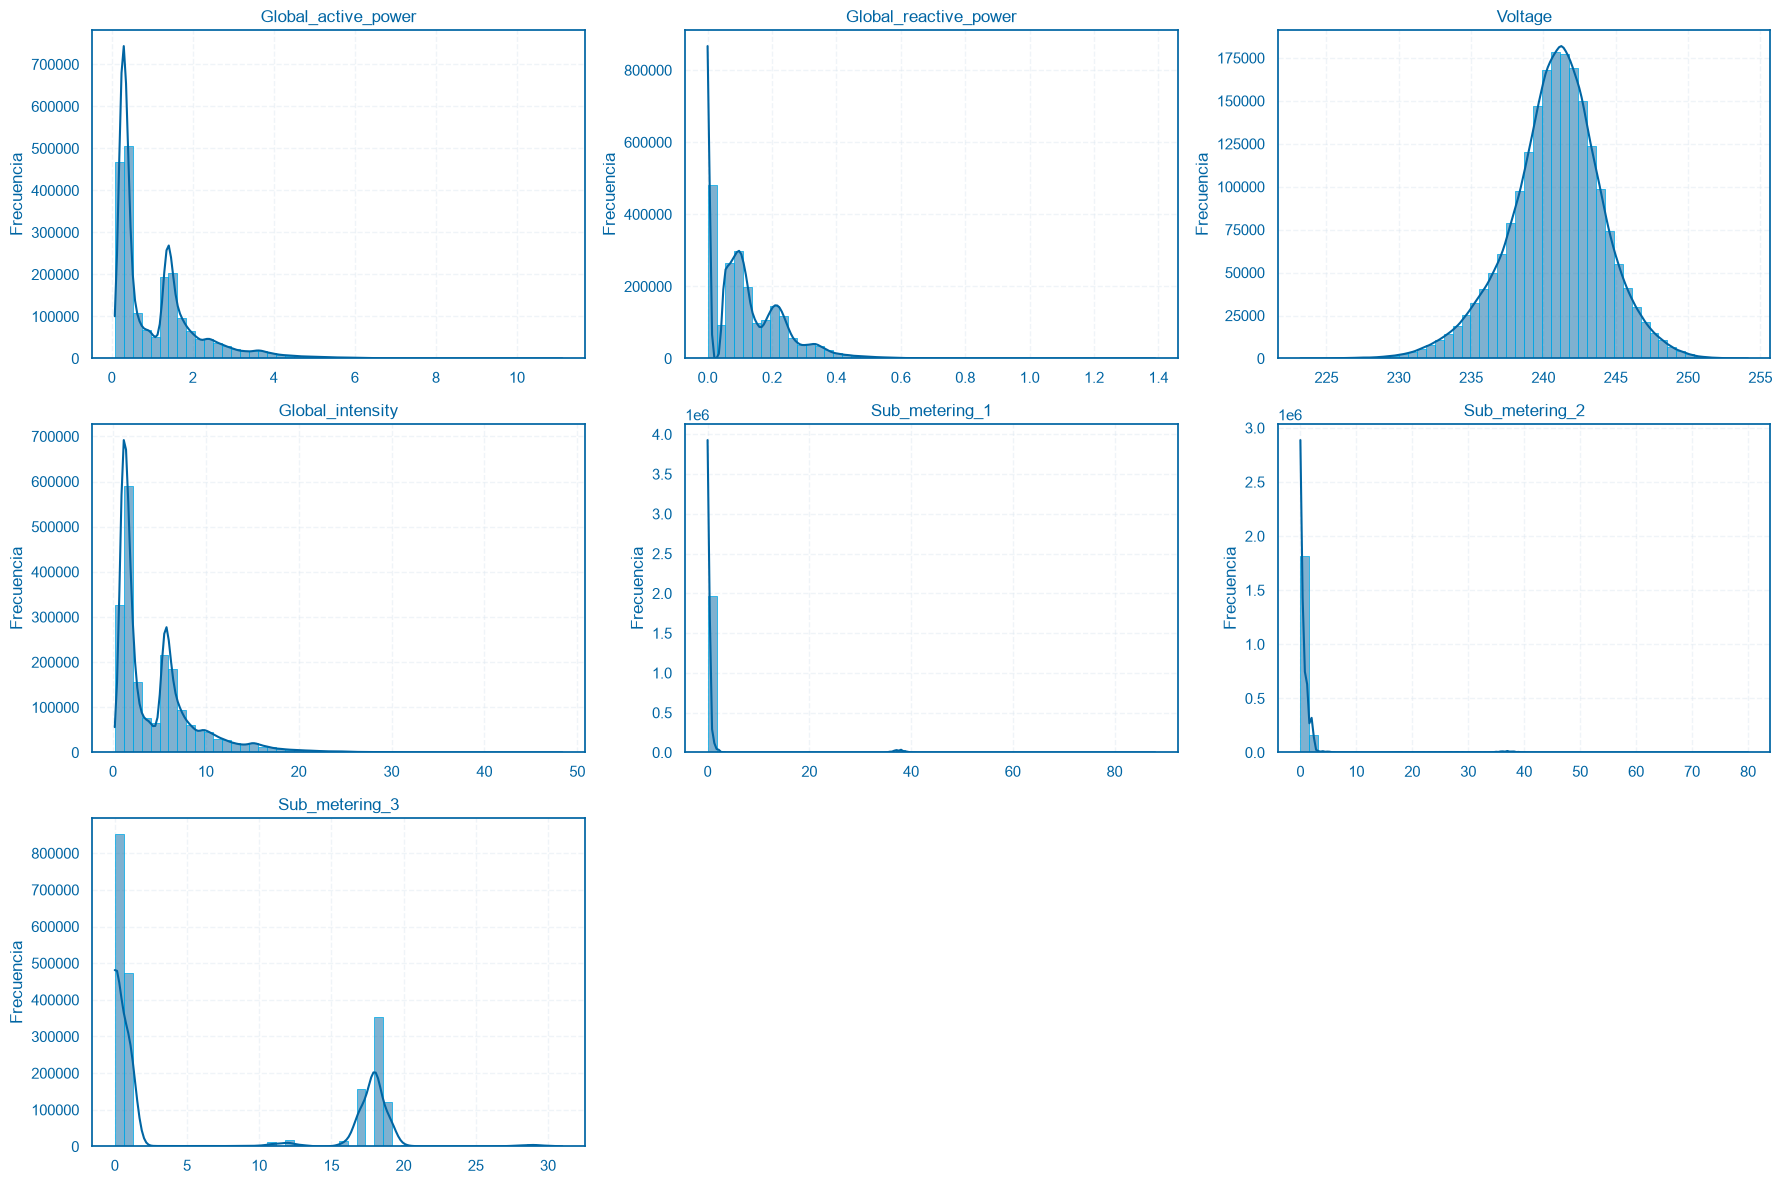

In [15]:
AZUL = "#0065A3"
AZUL_CLARO = "#00A9E7"
GRIS_CLARO = "#D9E5EE"

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": AZUL,
    "axes.labelcolor": AZUL,
    "axes.titlecolor": AZUL,
    "xtick.color": AZUL,
    "ytick.color": AZUL,
    "grid.color": GRIS_CLARO,
    "grid.linestyle": "--",
    "grid.alpha": 0.4,
})

df = eraw.copy()
variables = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
for ax, col in zip(axes, variables):
    sns.histplot(
        data=df,
        x=col,
        bins=50,
        kde=True,
        color=AZUL,
        edgecolor=AZUL_CLARO,
        ax=ax
    )
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia")

for ax in axes[len(variables):]:
    ax.axis("off")
plt.tight_layout()
plt.show()


### 3.10.3 Valores Atípicos

In [16]:
df = eraw.copy()

columnas_numericas = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
]

for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")

mascara_extremos = pd.Series(False, index=df.index)
resumen_extremos = []

for col in columnas_numericas:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    if pd.isna(iqr) or iqr == 0:
        continue

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    mascara_col = (df[col] < limite_inferior) | (df[col] > limite_superior)
    mascara_extremos |= mascara_col

    resumen_extremos.append({
        "Columna": col,
        "Valores_extremos": int(mascara_col.sum())
    })

total_extremos = int(mascara_extremos.sum())
print(f"Total de registros con valores extremos: {total_extremos}")

resumen_extremos = pd.DataFrame(resumen_extremos)
if not resumen_extremos.empty:
    resumen_extremos["%"] = (resumen_extremos["Valores_extremos"] / len(df) * 100).round(2)
    resumen_extremos = resumen_extremos[resumen_extremos["Valores_extremos"] > 0]
    resumen_extremos = resumen_extremos.sort_values(by="Valores_extremos", ascending=False)

resumen_extremos


Total de registros con valores extremos: 208781


,Columna,Valores_extremos,%
3,Global_intensity,100961,4.86
0,Global_active_power,94907,4.57
4,Sub_metering_2,77151,3.72
2,Voltage,51067,2.46
1,Global_reactive_power,40420,1.95


Hallazgos: 

* Se identificaron 208,781 registros con al menos un outliner.
* Las variables que se ubican fuera del rango estadísticamente esperado son las siguientes: 
            * Global_intensity:	Con 100961	registros atípicos. Esto puede deberse a que, el atributo es muy sensible a cambios de consumo.
            * Global_active_power: Con 94907 registros atípicos. Valor que puede entenderse ya que, el consumo eléctrico sube y baja mucho en ciertos momentos del día.
            * Sub_metering_2: Con 77151 registros atípicos. Tomando en cuenta que dicho indicador corresponde al cuarto de lavado, es de esperarse que cuente con fluctuaciones de enegías altas ya que, es una área con uso intermitente y por ciclos. Por otra parte si varios de los equipos se encienden al mismo tiempo, el consumo sube de forma brusca y aparece como un pico.
            * Voltage: Con 51067 registros atípicos. Como el suministro de la red suele ser de magnitud estable, es posible que, pequeñas variaciones por la carga del hogar, la regulación de la red y el momento del día pueden hacer que el criterio marque muchas lecturas como extremas.
            * Global_reactive_power: Con 40420 registros atípicos. Como la potencia reactiva depende de cargas eléctricas que no consumen energía activa de manera constante, es normal encontrar variaciones intermitentes. 

Hallazgos Generales EDA:

* Global_active_power: El análisis indica que la potencia activa total consumida por la vivienda, presenta una media de 1,09 kW con una desviación estándar de 1,06 kW, mediana de 0,60 kW y moda de 0,22 kW.
Al evaluar la desviación estándar con el promedio se logra identificar que, es casi tan grande como la media. Señalando que existe una alta variabilidad en el consumo de la electricidad. Dicha variabilidad también se encuentra influencia por una bimodalidad, la cual se caracteriza por un patrón de consumo bajo la mayor parte del tiempo y otro de consumo levemente alto. A su vez se suma los valores atípicos (4.86%). Al estudiar el histograma, se observa una distribución sesgada hacia la derecha, debido a la presencia de algunos períodos con consumos elevados. 
Éstos comportamientos se deben a la sensibilidad antes mencionada a los cambios de consumo. 

* Global_reactive_power: Representa la potencia reactiva total. Su media es 0,12 kW, la desviación estándar 0,11 kW, la mediana 0,10 kW y la moda 0,00 kW. En el histograma, se logran apreciar varios picos, lo que sugiere que el consumo no se concentra en un único nivel, sino que existen diferentes niveles de demanda asociados posiblemente a distintos patrones de uso de los electrodomésticos. Distinguida por una asimetría positiva (skewness = 1,26) y el 1,97% de atípicos confirman ese comportamiento irregular.
    
* Voltage: El suministro del voltaje se da en V. Tiene una media de 240,8399 V, desviación estándar de 3,2400 V, mediana de 241,0100 V y moda de 241,1800 V. La diferencia entre media, mediana y moda es pequeña, por lo que la variable es bastante estable y casi simétrica, con una leve asimetría negativa (skewness = -0,33). Solo se detecta 2,49% de valores atípicos, lo que confirma que el voltaje se mantiene relativamente uniforme alrededor de 241 V.
   
* Global_intensity: Representa la intensidad total de corriente en A. Presenta una media de 4,63 A, desviación estándar de 4,44 A, mediana de 2,60 A y moda de 1,0000 A. La desviación estándar es casi igual a la media, lo que refleja una variabilidad elevada. Su distribución tiene sesgo positivo (skewness = 1,85) y 4,93% de atípicos, indicando que la corriente se mantiene baja la mayor parte del tiempo, pero con picos importantes marcados por una alta concentración de observaciones en niveles bajos de intensidad y un segundo nivel de concentración alrededor de 5‒7 A. 

* Sub_metering_1: Registra el consumo del circuito 1, asociado principalmente a la cocina. Su media es 1,12 Wh, la desviación estándar es 6,15 Wh, la mediana 0 Wh y la moda 0 Wh. La mayor parte del tiempo permanece en cero, pero presenta picos altos cuando ese circuito se utiliza, lo que produce una distribución muy asimétrica hacia la derecha (skewness = 5,94) y 4,18% de valores atípicos.

* Sub_metering_2: Registra el consumo del circuito 2, vinculado al área de lavado. Su media es 1,30 Wh, la desviación estándar de 5,82 Wh, mediana 0 Wh y moda 0 Wh. La concentración en cero es muy alta, pero aparecen picos ocasionales de consumo, por eso la distribución es fuertemente sesgada a la derecha (skewness = 7,09) y el 3,72% de atípicos.

* Sub_metering_3: Corresponde al circuito 3, normalmente asociado al calentador de agua o climatización. Presenta una media de 6,46 Wh, desviación estándar de 8,44 Wh, mediana de 1 Wh y moda de 0 Wh. La mayor parte de los registros se concentran en valores bajos, pero existe un segundo grupo importante alrededor de 17‒18 Wh, lo que explica su bimodalidad. Además, su asimetría positiva (skewness = 0,72) y el 1,28% de atípicos muestran que el comportamiento es irregular y con consumos intermitentes altos.


## 3.10.4 EDA Variables Temporales

Timestamp inválidos: 0
Inicio del periodo: 2006-12-16 17:24:00
Fin del periodo: 2010-11-26 21:02:00
Duplicados temporales: 0
Gaps mayores a 1 minuto: 0


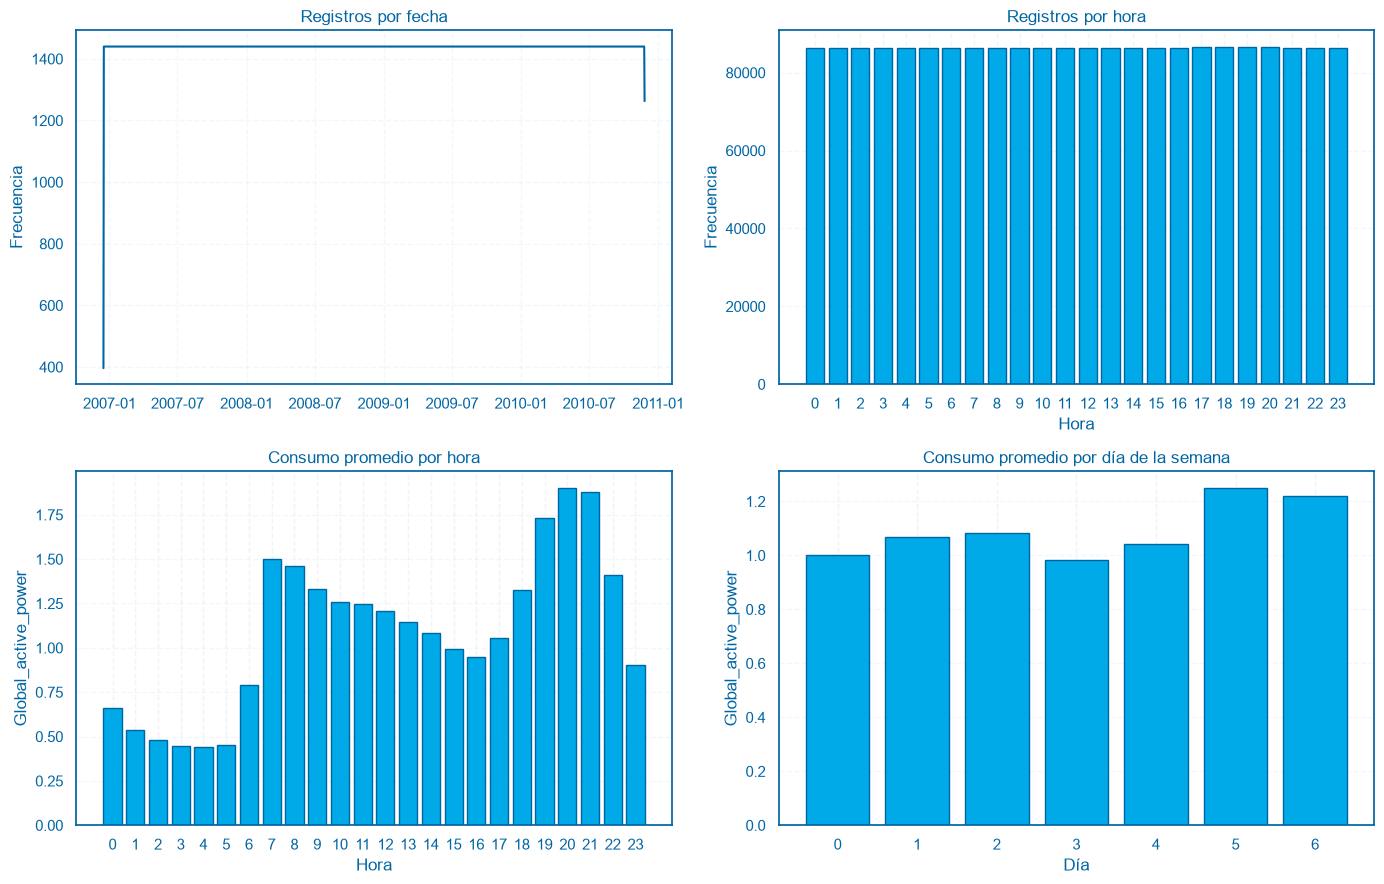

In [20]:
df = eraw.copy()

df["fecha_hora"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

df = df.sort_values("fecha_hora").reset_index(drop=True)
df["hour"] = df["fecha_hora"].dt.hour
df["dayofweek"] = df["fecha_hora"].dt.dayofweek
df["gap_minutos"] = df["fecha_hora"].diff().dt.total_seconds().div(60)

print("Timestamp inválidos:", df["fecha_hora"].isna().sum())
print("Inicio del periodo:", df["fecha_hora"].min())
print("Fin del periodo:", df["fecha_hora"].max())
print("Duplicados temporales:", df["fecha_hora"].duplicated().sum())
print("Gaps mayores a 1 minuto:", (df["gap_minutos"] > 1).sum())

registros_por_fecha = df["fecha_hora"].dt.date.value_counts().sort_index()
registros_por_hora = df["hour"].value_counts().sort_index()
consumo_por_hora = df.groupby("hour")["Global_active_power"].mean()
consumo_por_dia = df.groupby("dayofweek")["Global_active_power"].mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(registros_por_fecha.index, registros_por_fecha.values, color="#0065A3")
axes[0, 0].set_title("Registros por fecha")
axes[0, 0].set_ylabel("Frecuencia")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].bar(registros_por_hora.index, registros_por_hora.values, color="#00A9E7", edgecolor="#0065A3")
axes[0, 1].set_title("Registros por hora")
axes[0, 1].set_xlabel("Hora")
axes[0, 1].set_ylabel("Frecuencia")
axes[0, 1].set_xticks(range(24))
axes[0, 1].grid(axis="y", alpha=0.3)

axes[1, 0].bar(consumo_por_hora.index, consumo_por_hora.values, color="#00A9E7", edgecolor="#0065A3")
axes[1, 0].set_title("Consumo promedio por hora")
axes[1, 0].set_xlabel("Hora")
axes[1, 0].set_ylabel("Global_active_power")
axes[1, 0].set_xticks(range(24))
axes[1, 0].grid(axis="y", alpha=0.3)

axes[1, 1].bar(consumo_por_dia.index, consumo_por_dia.values, color="#00A9E7", edgecolor="#0065A3")
axes[1, 1].set_title("Consumo promedio por día de la semana")
axes[1, 1].set_xlabel("Día")
axes[1, 1].set_ylabel("Global_active_power")
axes[1, 1].set_xticks(range(7))
axes[1, 1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Hallazgos:
* La distribución de registros por hora es bastante uniforme, lo que sugiere que la serie temporal fue capturada de forma regular y no presenta sesgos importantes de cobertura según la hora del día.
* El consumo promedio por hora muestra un patrón diario claro donde los valores más bajos se observan en la madrugada, aproximadamente entre las 2:00 y 5:00.
* A partir de la mañana el consumo comienza a subir, se mantiene en niveles intermedios durante buena parte del día y alcanza su punto más alto en la noche, especialmente entre las 19:00 y 21:00, donde se observan los mayores promedios de Global_active_power.
* Después de las 21:00 el consumo vuelve a descender, lo que confirma un comportamiento coherente con rutinas domésticas.
* Por día de la semana, el consumo promedio es relativamente estable, pero se aprecia un incremento en los días 5 y 6. Esos valores corresponden a sábado y domingo, por lo que el fin de semana concentra los niveles promedio más altos de consumo.
* En conjunto, el EDA temporal indica que el dataset conserva una estructura cronológica consistente y que el consumo eléctrico está fuertemente influido por patrones horarios y semanales de uso del hogar.

## 3.11 Validación automáticas previa al entrenamiento
Antes de entrenar, el pipeline ejecuta un conjunto de reglas automáticas para verificar que el dataset sea usable y consistente.


In [17]:
def validar_datos_crudos(
    df,
    target_col="Global_active_power",
    min_rows=1_000_000,
    dup_threshold=0.001,
    null_threshold=0.02,
    strict=False
):
    df = df.copy()

    columnas_esperadas = [
        "Date", "Time",
        "Global_active_power", "Global_reactive_power", "Voltage",
        "Global_intensity", "Sub_metering_1", "Sub_metering_2", "Sub_metering_3"
    ]

    num_cols = [
        "Global_active_power", "Global_reactive_power", "Voltage",
        "Global_intensity", "Sub_metering_1", "Sub_metering_2", "Sub_metering_3"
    ]

    energia_cols = [
        "Global_active_power", "Global_reactive_power", "Global_intensity",
        "Sub_metering_1", "Sub_metering_2", "Sub_metering_3"
    ]

    faltantes = [c for c in columnas_esperadas if c not in df.columns]
    fecha_hora = pd.to_datetime(
        df["Date"].astype(str) + " " + df["Time"].astype(str),
        format="%d/%m/%Y %H:%M:%S",
        errors="coerce"
    ) if {"Date", "Time"}.issubset(df.columns) else pd.Series(pd.NaT, index=df.index)

    # Convertir a numérico solo para evaluar consistencia
    for c in num_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    nulos_max = df[num_cols].isna().mean().max() if num_cols else 1
    target_nulos = int(df[target_col].isna().sum()) if target_col in df.columns else len(df)
    dup_exactos = df.duplicated().mean()
    fechas_invalidas = int(fecha_hora.isna().sum())

    inconsistencias_fisicas = 0
    if set(energia_cols).issubset(df.columns) and "Voltage" in df.columns:
        energia_negativa = (df[energia_cols] < 0).any(axis=1)
        voltaje_no_positivo = df["Voltage"] <= 0
        inconsistencias_fisicas = int((energia_negativa | voltaje_no_positivo).sum())

    reglas = [
        {
            "Regla": "Columnas esperadas presentes",
            "Cumple": len(faltantes) == 0,
            "Valor": "OK" if not faltantes else ", ".join(faltantes),
            "Umbral": "Sin faltantes",
            "Detalle": "Verifica que la estructura base del dataset sea la esperada."
        },
        {
            "Regla": "Volumen mínimo de registros",
            "Cumple": len(df) > min_rows,
            "Valor": f"{len(df):,}",
            "Umbral": f"> {min_rows:,}",
            "Detalle": "Evita trabajar con un dataset demasiado pequeño."
        },
        {
            "Regla": "Duplicados exactos",
            "Cumple": dup_exactos < dup_threshold,
            "Valor": f"{dup_exactos * 100:.4f}%",
            "Umbral": f"< {dup_threshold * 100:.2f}%",
            "Detalle": "Controla filas repetidas en el conjunto crudo."
        },
        {
            "Regla": "Target sin nulos",
            "Cumple": target_nulos == 0,
            "Valor": target_nulos,
            "Umbral": "0",
            "Detalle": "La variable objetivo debe estar completa antes de entrenar."
        },
        {
            "Regla": "Nulos numéricos máximos",
            "Cumple": nulos_max <= null_threshold,
            "Valor": f"{nulos_max * 100:.4f}%",
            "Umbral": f"<= {null_threshold * 100:.2f}%",
            "Detalle": "Los faltantes deben mantenerse dentro del patrón detectado en la ingesta."
        },
        {
            "Regla": "Fecha y hora parseables",
            "Cumple": fechas_invalidas == 0,
            "Valor": fechas_invalidas,
            "Umbral": "0",
            "Detalle": "Garantiza que la serie temporal sea reconstruible con `Date` y `Time`."
        },
        {
            "Regla": "Variables energéticas no negativas",
            "Cumple": inconsistencias_fisicas == 0,
            "Valor": inconsistencias_fisicas,
            "Umbral": "0",
            "Detalle": "No deben existir consumos físicos imposibles."
        },
    ]

    reporte = pd.DataFrame(reglas)
    if strict and not reporte["Cumple"].all():
        fallidas = reporte.loc[~reporte["Cumple"], "Regla"].tolist()
        raise ValueError(f"Validación fallida en: {', '.join(fallidas)}")
    return reporte

reporte_validacion = validar_datos_crudos(eraw, strict=False)
display(reporte_validacion)

if reporte_validacion["Cumple"].all():
    print("Validación aprobada: el dataset está listo para entrenar.")
else:
    print("Validación con observaciones: corrige las reglas marcadas como Falso antes de entrenar.")


,Regla,Cumple,Valor,Umbral,Detalle
0,Columnas esperadas presentes,True,OK,Sin faltantes,Verifica que la estructura base del dataset se...
1,Volumen mínimo de registros,True,"2,075,259","> 1,000,000",Evita trabajar con un dataset demasiado pequeño.
2,Duplicados exactos,True,0.0000%,< 0.10%,Controla filas repetidas en el conjunto crudo.
3,Target sin nulos,False,25979,0,La variable objetivo debe estar completa antes...
4,Nulos numéricos máximos,True,1.2518%,<= 2.00%,Los faltantes deben mantenerse dentro del patr...
5,Fecha y hora parseables,True,0,0,Garantiza que la serie temporal sea reconstrui...
6,Variables energéticas no negativas,True,0,0,No deben existir consumos físicos imposibles.


Validación con observaciones: corrige las reglas marcadas como Falso antes de entrenar.


Hallazgos:
* La validación fue éxitosa. 

## 3.11 Copia del dataset crudo

In [21]:
eraw_crudo = eraw[cols_9].copy(deep=True)

print("Copia creada:", eraw_crudo.shape)

Copia creada: (2075259, 9)
